<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/vanishing_gradient_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vanishing Gradient Problem (Concept)

Deep Neural Network training করার সময় backpropagation এর মাধ্যমে gradient
প্রতিটি layer দিয়ে propagate হয়।

কিন্তু কিছু activation function (যেমন Sigmoid / Tanh) ব্যবহার করলে
gradient বারবার ছোট হতে হতে প্রায় 0 হয়ে যায়।

এই অবস্থাকে বলা হয় Vanishing Gradient Problem.

যখন gradient খুব ছোট হয়ে যায় তখন:

• weight update প্রায় বন্ধ হয়ে যায়  
• network শেখা বন্ধ করে দেয়  
• early layers train হতে পারে না  

এই notebook-এ আমরা code দিয়ে দেখবো:

1️⃣ Deep network + sigmoid activation  
2️⃣ training এর সময় weight change observe করা  
3️⃣ gradient ছোট হয়ে যাচ্ছে কিনা দেখা

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


In [3]:

# reproducibility
torch.manual_seed(42)

# Dataset

আমরা sklearn এর make_moons dataset ব্যবহার করছি।

এই dataset:

• non-linear classification problem
• deep network দরকার
• training behaviour observe করা সহজ

এখানে input feature = 2
target = binary class

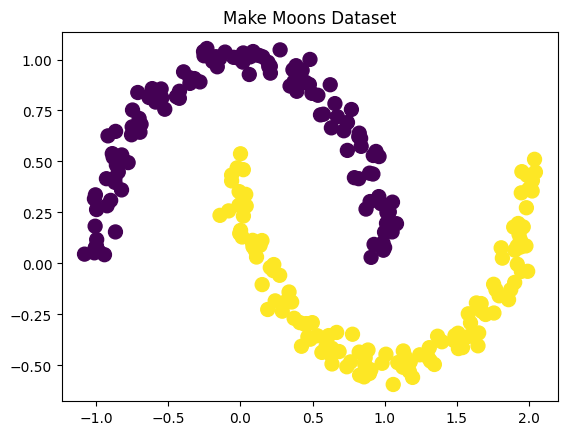

In [4]:
# =========================
# 1. Dataset
# =========================

X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, s=100)
plt.title("Make Moons Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [10]:
# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)


In [5]:
# =========================
# 2. Model
# =========================

class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,1), nn.Sigmoid(),
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()

# Deep Neural Network with Sigmoid

এই model এ আমরা:

• অনেক hidden layer ব্যবহার করেছি
• activation function হিসেবে Sigmoid ব্যবহার করেছি

Sigmoid activation এর derivative খুব ছোট হয়ে যায়
যখন input বড় বা ছোট হয়।

Backpropagation এ gradient layer থেকে layer এ propagate হওয়ার সময়
বারবার ছোট হতে থাকে।

Result:

Early layers এ gradient প্রায় 0 হয়ে যায়।

In [6]:
# =========================
# 3. Loss + Optimizer
# =========================

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)




In [7]:


# =========================
# 4. Save Initial Weights
# =========================

old_weights = model.net[0].weight.data.clone().numpy()

In [8]:
# for plotting weight movement
initial_weights = model.net[0].weight.data.clone()
weight_changes = []

In [11]:
# =========================
# 5. Training
# =========================

epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    # track weight movement
    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 0 Loss: 0.6968
Epoch 10 Loss: 0.6942
Epoch 20 Loss: 0.6931
Epoch 30 Loss: 0.6930
Epoch 40 Loss: 0.6930
Epoch 50 Loss: 0.6930
Epoch 60 Loss: 0.6929
Epoch 70 Loss: 0.6929
Epoch 80 Loss: 0.6929
Epoch 90 Loss: 0.6929


# Training Process

Training loop এ আমরা নিচের step follow করি:

1. forward pass
2. loss calculation
3. backward pass
4. weight update

এখানে আমরা weight change track করছি
যাতে বুঝতে পারি training এর সময় weight কতটা update হচ্ছে।